# 01 · EDA del dataset de la Champions League

Este es el análisis exploratorio que dio origen a **todo el curso** (Ejercicio 1 / Lab 02).
Cada hallazgo de aquí se convirtió después en una decisión de preprocesamiento:
en el pipeline de la Actividad 1, en la calibración de la Actividad 3, en la API de la
Actividad 4 y en el `limpiar.py` del Ejercicio 3.

**Pregunta de negocio propuesta:** ¿podemos clasificar el resultado de un partido
(`Home Win`, `Away Win`, `Draw`) a partir de sus estadísticas de juego?

Ruta del análisis:
1. Cargar y mirar la forma cruda.
2. Encontrar las filas vacías (y entender por qué existen).
3. Clasificar las columnas en los cuatro tipos de variables.
4. Convertir el "texto que es número" (`'63%'`, `'3 of 10'`) y validar la conversión.
5. Explicar los nulos que quedan.
6. Mirar la variable objetivo (desbalance y baseline).
7. Detectar la **fuga de información**: directa y también una indirecta.
8. Correlaciones y gráficos.
9. Tabla final: hallazgo → decisión en el curso.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
plt.rcParams["figure.dpi"] = 100

## 1. Carga y primera mirada

Lo primero en cualquier EDA: `shape`, `dtypes`, `head()`. Ojo con `dtypes`:
`object`/`str` significa "texto". Si una columna que debería ser número aparece como
texto, ya tenemos un hallazgo.

In [2]:
df_crudo = pd.read_csv("../datos/champions_league_matches.csv")
print("Forma cruda:", df_crudo.shape)
print()
print(df_crudo.dtypes.astype(str).value_counts())
df_crudo.head(3)

Forma cruda: (151, 18)

str        14
float64     4
Name: count, dtype: int64


,date,home_team,away_team,score,venue,referee,home_possession,away_possession,home_shots_on_target,away_shots_on_target,home_saves,away_saves,home_shots_on_target_pct,away_shots_on_target_pct,home_saves_pct,away_saves_pct,result,winner
0,2025-09-16,PSV,Union SG,1–3,Philips Stadion,Anthony Taylor,63%,37%,3 of 10,8 of 18,4 of 8,2 of 3,30.0,44.4,50.0,66.7,Away Win,Union SG
1,2025-09-16,Athletic Club,Arsenal,0–2,San Mamés,Donatas Rumšas,38%,62%,2 of 11,6 of 11,4 of 6,2 of 2,18.2,54.5,66.7,100.0,Away Win,Arsenal
2,2025-09-16,Tottenham Hotspur,Villarreal,1–0,Tottenham Hotspur Stadium,Rade Obrenović,58%,42%,1 of 9,0 of 10,0 of 0,1 of 1,11.1,0.0,NaN,100.0,Home Win,Tottenham Hotspur


**Interpretación:** 151 filas y 18 columnas, pero **solo 4 columnas son numéricas**
(`float64`, los `*_pct`). Las otras 14 se leyeron como texto, incluidas la posesión, los
tiros y las atajadas, que obviamente son números. Primera alarma.

## 2. Filas totalmente vacías

`df.isna().all(axis=1)` marca las filas donde **todas** las columnas son nulas.

In [3]:
vacias = df_crudo.index[df_crudo.isna().all(axis=1)].tolist()
print("Filas totalmente vacías:", len(vacias))
print("Índices:", vacias)
print("Distancia entre ellas:", np.diff(vacias).tolist())

Filas totalmente vacías: 7
Índices: [18, 37, 56, 75, 94, 113, 132]
Distancia entre ellas: [19, 19, 19, 19, 19, 19]


**Interpretación:** hay 7 filas vacías y aparecen **cada 19 filas** (18 partidos + 1
separador). No son datos faltantes "al azar": son separadores visuales entre bloques de
partidos (jornadas), probablemente porque la tabla se copió de una página web. 144
partidos = 8 bloques de 18. Comprobémoslo:

In [4]:
df = df_crudo.dropna(how="all").reset_index(drop=True)
bloque = np.repeat(np.arange(8), 18)
print("Partidos reales:", len(df))
resumen_bloques = (df.assign(bloque=bloque)
                     .groupby("bloque")["date"].agg(["min", "max", "count"]))
resumen_bloques

Partidos reales: 144


,min,max,count
bloque,,,
0,2025-09-16,2025-09-18,18
1,2025-09-30,2025-10-01,18
2,2025-10-21,2025-10-22,18
3,2025-11-04,2025-11-05,18
4,2025-11-25,2025-11-26,18
5,2025-12-09,2025-12-10,18
6,2026-01-20,2026-01-21,18
7,2026-01-28,2026-01-28,18


**Interpretación:** quedan **144 partidos** en 8 bloques de 18. Cada bloque cubre las
fechas de una jornada (una jornada de Champions se juega en 2-3 días). Decisión del
curso: `df.dropna(how="all")` es el **primer paso** del filtrado en todos los repos.

¿Por qué importa? Si no las quitas, `value_counts()` y las proporciones de clase salen
mal, y un `SimpleImputer` rellenaría 7 "partidos fantasma" con la mediana.

## 3. Los cuatro tipos de variables (más las que no entran)

Clasificar columnas es la decisión más importante del EDA, porque **cada tipo necesita
un tratamiento distinto** en el pipeline.

In [5]:
tipos = pd.DataFrame([
    ("home_shots_on_target_pct, away_shots_on_target_pct, home_saves_pct, away_saves_pct",
     "Numérica ya limpia", "float en el CSV", "imputar (mediana) → escalar"),
    ("home_possession, away_possession", "Texto que es número (porcentaje)", "'63%'",
     "quitar '%' → float → imputar → escalar"),
    ("home/away_shots_on_target, home/away_saves", "Texto que es número (razón)", "'3 of 10'",
     "separar en hechos=3 e intentos=10 → imputar → escalar"),
    ("home_team, away_team", "Categórica nominal", "'PSV'",
     "imputar (moda) → One-Hot"),
    ("date", "Fecha", "'2025-09-16'", "se descarta (podría dar 'jornada' o 'mes')"),
    ("venue, referee", "Categórica de alta cardinalidad", "'San Mamés'", "se descarta"),
    ("score, winner", "FUGA: revela el resultado", "'1–3', 'Union SG'", "se descarta SIEMPRE"),
    ("result", "Objetivo (multiclase)", "'Away Win'", "es la y"),
], columns=["columnas", "tipo", "ejemplo", "tratamiento en el curso"])
tipos

,columnas,tipo,ejemplo,tratamiento en el curso
0,"home_shots_on_target_pct, away_shots_on_target...",Numérica ya limpia,float en el CSV,imputar (mediana) → escalar
1,"home_possession, away_possession",Texto que es número (porcentaje),'63%',quitar '%' → float → imputar → escalar
2,"home/away_shots_on_target, home/away_saves",Texto que es número (razón),'3 of 10',separar en hechos=3 e intentos=10 → imputar → ...
3,"home_team, away_team",Categórica nominal,'PSV',imputar (moda) → One-Hot
4,date,Fecha,'2025-09-16',se descarta (podría dar 'jornada' o 'mes')
5,"venue, referee",Categórica de alta cardinalidad,'San Mamés',se descarta
6,"score, winner",FUGA: revela el resultado,"'1–3', 'Union SG'",se descarta SIEMPRE
7,result,Objetivo (multiclase),'Away Win',es la y


## 4. Convertir el "texto que es número"

### 4.1 Posesión: `'63%'` → `63.0`
Quitamos el símbolo y convertimos. **Validación de sentido común:** la posesión del
local más la del visitante debería sumar 100.

In [6]:
pos_local = df["home_possession"].str.rstrip("%").astype(float)
pos_visita = df["away_possession"].str.rstrip("%").astype(float)
print(pos_local.describe().round(1))
print("\nSuma local + visita:")
print((pos_local + pos_visita).value_counts())

count    144.0
mean      51.0
std       11.9
min       24.0
25%       42.8
50%       51.0
75%       59.2
max       77.0
Name: home_possession, dtype: float64

Suma local + visita:
100.0    132
101.0     12
Name: count, dtype: int64


**Interpretación:** la posesión del local va de 24 % a 77 % con media de 51 %.
132 partidos suman 100 y 12 suman 101: es **redondeo de la fuente** (por ejemplo 50.6 % y
50.4 % publicados como 51 % y 50 %), no un error que haya que corregir. Validar así
evita sorpresas: si hubiera sumas de 60 o 140, el problema sería de parseo.

### 4.2 Tiros a puerta y atajadas: `'3 of 10'` → `3` y `10`
Una sola columna de texto esconde **dos números**: los hechos y los intentos. Con una
expresión regular `(\d+)\s*of\s*(\d+)` los separamos. La Actividad 1 lo empaquetó en el
transformador `RatioATexto`.

In [7]:
def separar_ratio(serie):
    partes = serie.str.extract(r"(\d+)\s*of\s*(\d+)").astype(float)
    return partes[0], partes[1]

num = pd.DataFrame({"home_possession": pos_local, "away_possession": pos_visita})
for col in ["home_shots_on_target", "away_shots_on_target", "home_saves", "away_saves"]:
    num[f"{col}_hechos"], num[f"{col}_intentos"] = separar_ratio(df[col])
for col in ["home_shots_on_target_pct", "away_shots_on_target_pct", "home_saves_pct", "away_saves_pct"]:
    num[col] = df[col]
num.head()

,home_possession,away_possession,home_shots_on_target_hechos,home_shots_on_target_intentos,away_shots_on_target_hechos,away_shots_on_target_intentos,home_saves_hechos,home_saves_intentos,away_saves_hechos,away_saves_intentos,home_shots_on_target_pct,away_shots_on_target_pct,home_saves_pct,away_saves_pct
0,63.0,37.0,3.0,10.0,8.0,18.0,4.0,8.0,2.0,3.0,30.0,44.4,50.0,66.7
1,38.0,62.0,2.0,11.0,6.0,11.0,4.0,6.0,2.0,2.0,18.2,54.5,66.7,100.0
2,58.0,42.0,1.0,9.0,0.0,10.0,0.0,0.0,1.0,1.0,11.1,0.0,NaN,100.0
3,53.0,47.0,3.0,14.0,5.0,10.0,2.0,5.0,1.0,3.0,21.4,50.0,40.0,33.3
4,52.0,48.0,7.0,19.0,5.0,10.0,1.0,5.0,3.0,7.0,36.8,50.0,20.0,42.9


**Validación cruzada entre columnas:** el CSV ya trae `home_shots_on_target_pct`.
Si nuestra conversión es correcta, `hechos / intentos * 100` debería coincidir.

In [8]:
calc = (num["home_shots_on_target_hechos"] / num["home_shots_on_target_intentos"] * 100).round(1)
print("¿Coincide con home_shots_on_target_pct?", np.allclose(calc, df["home_shots_on_target_pct"]))
print("Diferencia máxima:", (calc - df["home_shots_on_target_pct"]).abs().max())

¿Coincide con home_shots_on_target_pct? True
Diferencia máxima: 0.0


**Interpretación:** coincide al 100 %. Dos lecturas importantes:
1. La conversión está bien hecha.
2. Las columnas `*_pct` son **redundantes**: se pueden calcular de las otras. Información
   duplicada no es un error, pero conviene saberlo (las correlaciones serán altas).

## 5. Los nulos que quedan: `home_saves_pct`
Tras quitar las filas vacías, ¿queda algún nulo?

In [9]:
print(num.isna().sum()[num.isna().sum() > 0])
print()
print(df.loc[df["home_saves_pct"].isna(), ["home_team", "away_team", "home_saves", "home_saves_pct"]])

home_saves_pct    3
dtype: int64

             home_team    away_team home_saves  home_saves_pct
2    Tottenham Hotspur   Villarreal     0 of 0             NaN
90       Bayern Munich  Sporting CP     0 of 0             NaN
130             Monaco     Juventus     0 of 0             NaN


**Interpretación:** 3 nulos en `home_saves_pct`, y los tres son partidos con `'0 of 0'`
atajadas: el visitante no tiró ni una vez a puerta, así que el porcentaje es **0/0,
indefinido**. No es un dato perdido, es una división entre cero. Decisión del curso:
imputar con la mediana dentro del pipeline (`SimpleImputer`), y en la Actividad 3 se
calibró `median` vs `mean` para comprobar que la decisión casi no importa.

## 6. La variable objetivo: `result`

          partidos  proporción
result                        
Home Win        71       0.493
Away Win        48       0.333
Draw            25       0.174

Baseline 'siempre Home Win': accuracy = 0.493


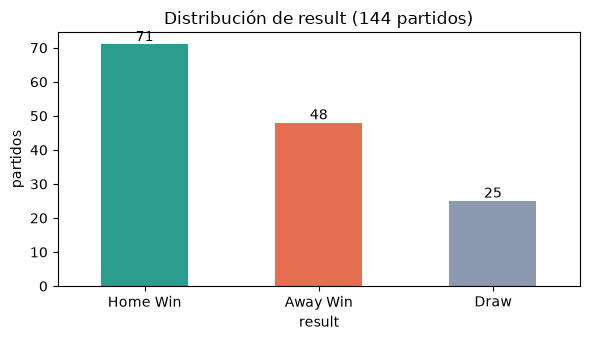

In [10]:
conteo = df["result"].value_counts()
proporcion = df["result"].value_counts(normalize=True).round(3)
print(pd.DataFrame({"partidos": conteo, "proporción": proporcion}))
print(f"\nBaseline 'siempre Home Win': accuracy = {proporcion.max():.3f}")

fig, ax = plt.subplots(figsize=(6, 3.5))
conteo.plot.bar(ax=ax, rot=0, color=["#2a9d8f", "#e76f51", "#8d99ae"])
ax.set_title("Distribución de result (144 partidos)")
ax.set_ylabel("partidos")
for i, v in enumerate(conteo):
    ax.text(i, v + 1, str(v), ha="center")
plt.tight_layout()
plt.show()

**Interpretación:** 71 victorias locales (49.3 %), 48 visitantes (33.3 %) y solo **25
empates (17.4 %)**. Dos consecuencias que atraviesan todo el curso:
- **Baseline:** un modelo tonto que siempre dice "gana el local" ya acierta 49.3 %.
  Cualquier modelo tiene que ganarle a eso (criterio de éxito de la Actividad 1 y
  compuerta de calidad del Ejercicio 3).
- **Desbalance:** el `accuracy` premia acertar la clase grande. Por eso desde la
  Actividad 3 se optimiza **`f1_macro`**, que da el mismo peso a los empates, y se separa
  con `stratify=y` para que los pocos empates queden en train y en test.

## 7. Fuga de información (data leakage)

**Definición:** una variable tiene fuga si contiene información que **no estaría
disponible en el momento de predecir** o que es, directa o indirectamente, la respuesta.

### 7.1 Fuga directa: `score` y `winner`
Si conoces el marcador, conoces el resultado. Lo demostramos derivando `result` solo
con `score` y solo con `winner`.

In [11]:
goles = df["score"].str.split("–", expand=True).astype(int)   # ojo: es un guion largo '–'
goles.columns = ["goles_local", "goles_visita"]
desde_score = np.select([goles.goles_local > goles.goles_visita,
                         goles.goles_local < goles.goles_visita],
                        ["Home Win", "Away Win"], "Draw")
desde_winner = np.where(df["winner"] == "Draw", "Draw",
                        np.where(df["winner"] == df["home_team"], "Home Win", "Away Win"))
print(f"result reconstruido desde score : {(desde_score == df['result']).mean():.0%} de acierto")
print(f"result reconstruido desde winner: {(desde_winner == df['result']).mean():.0%} de acierto")

result reconstruido desde score : 100% de acierto
result reconstruido desde winner: 100% de acierto


**Interpretación:** 100 % y 100 %. Un modelo con estas columnas tendría un accuracy
perfecto en el notebook y sería **inútil**: para saber el `score` el partido ya terminó.
Por eso `LEAKAGE_COLUMNS = ["score", "winner"]` se descarta en todos los repos.
(Detalle práctico: el marcador usa un guion largo `–`, no `-`; un `split("-")` falla.)

### 7.2 Fuga indirecta: los tiros y las atajadas "esconden" los goles

Un tiro a puerta termina en gol o en atajada. Entonces, aproximadamente:

$$\text{goles del local} \approx \text{tiros a puerta del local} - \text{atajadas del portero visitante}$$

Verifiquemos primero que las columnas se cruzan: las atajadas **intentadas** del portero
local deberían ser los tiros a puerta **acertados** del visitante.

In [12]:
cruce1 = (num["home_saves_intentos"] == num["away_shots_on_target_hechos"]).mean()
cruce2 = (num["away_saves_intentos"] == num["home_shots_on_target_hechos"]).mean()
print(f"home_saves intentos == away_shots_on_target hechos: {cruce1:.0%}")
print(f"away_saves intentos == home_shots_on_target hechos: {cruce2:.0%}")

goles_aprox_local = num["home_shots_on_target_hechos"] - num["away_saves_hechos"]
goles_aprox_visita = num["away_shots_on_target_hechos"] - num["home_saves_hechos"]
print(f"\nGoles del local exactamente = tiros a puerta - atajadas rivales: {(goles_aprox_local == goles.goles_local).mean():.1%}")
print(f"Goles de la visita exactamente = ...:                            {(goles_aprox_visita == goles.goles_visita).mean():.1%}")

desde_tiros = np.select([goles_aprox_local > goles_aprox_visita,
                         goles_aprox_local < goles_aprox_visita],
                        ["Home Win", "Away Win"], "Draw")
acc_regla = (desde_tiros == df["result"]).mean()
print(f"\nresult reconstruido con esa resta (sin score ni winner): {acc_regla:.1%}")

home_saves intentos == away_shots_on_target hechos: 100%
away_saves intentos == home_shots_on_target hechos: 100%

Goles del local exactamente = tiros a puerta - atajadas rivales: 70.8%
Goles de la visita exactamente = ...:                            81.9%

result reconstruido con esa resta (sin score ni winner): 84.7%


**Interpretación:** las columnas se cruzan al 100 % y la resta reproduce el marcador
exacto en muchos partidos (no en todos: autogoles, goles de rebote y diferencias en cómo
la fuente cuenta un "tiro a puerta"). Con una simple resta, **sin mirar `score` ni
`winner`**, se recupera el resultado en el porcentaje de arriba, muy por encima del 49.3 %
del baseline.

Esto explica una frase que aparece en las limitaciones de las Actividades 1 y 3: *"las
variables se conocen cuando el partido ya terminó, así que el modelo **explica** el
resultado más de lo que lo **predice**"*. No es fuga tan descarada como `score`, pero
un modelo con estas variables no sirve para predecir **antes** del partido. Para eso
habría que usar historial de cada equipo (rachas, goles promedio en partidos previos).

### 7.3 La fuga en números: un árbol con y sin `score`
Para sentir el efecto, entrenamos el mismo árbol con validación cruzada estratificada.

In [13]:
y = df["result"]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
arbol = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)

X_fuga = pd.concat([num, goles], axis=1)               # con los goles de cada equipo
X_dif = goles.assign(dif=goles.goles_local - goles.goles_visita)[["dif"]]  # diferencia de goles
X_limpio = num.fillna(num.median())                    # solo estadísticas de juego
X_resta = pd.DataFrame({"dif_goles_aprox": goles_aprox_local - goles_aprox_visita})

for nombre, X_ in [("goles sueltos (fuga directa)", X_fuga.fillna(0)),
                   ("solo diferencia de goles", X_dif),
                   ("solo estadísticas de juego", X_limpio),
                   ("solo la resta tiros - atajadas", X_resta)]:
    acc = cross_val_score(arbol, X_, y, cv=cv, scoring="accuracy")
    print(f"{nombre:32s} accuracy CV = {acc.mean():.3f} ± {acc.std():.3f}")

goles sueltos (fuga directa)     accuracy CV = 0.924 ± 0.086
solo diferencia de goles         accuracy CV = 1.000 ± 0.000
solo estadísticas de juego       accuracy CV = 0.652 ± 0.053
solo la resta tiros - atajadas   accuracy CV = 0.847 ± 0.061


**Interpretación:**
- Con los goles como columnas sueltas el árbol llega a **0.924** (un árbol corta por una
  variable a la vez y le cuesta "restar"); con la **diferencia de goles** llega a **1.000**.
  Eso es fuga directa: cualquier modelo serio la encuentra.
- Con todas las estadísticas de juego el árbol se queda en **0.652**, por encima del
  baseline de 0.493.
- Con **una sola variable construida a mano** (tiros a puerta − atajadas rivales) sube a
  **0.847**: mejor que con todas las estadísticas juntas. En el fondo, lo que el modelo
  aprende es a reconstruir el marcador.

## 8. Correlaciones

Calculamos la correlación de Pearson entre las variables numéricas ya convertidas y
un indicador `gana_local` (1 si `Home Win`, 0 si no). Sirve para ver redundancias
(variables casi idénticas entre sí) y cuáles se relacionan con el objetivo.

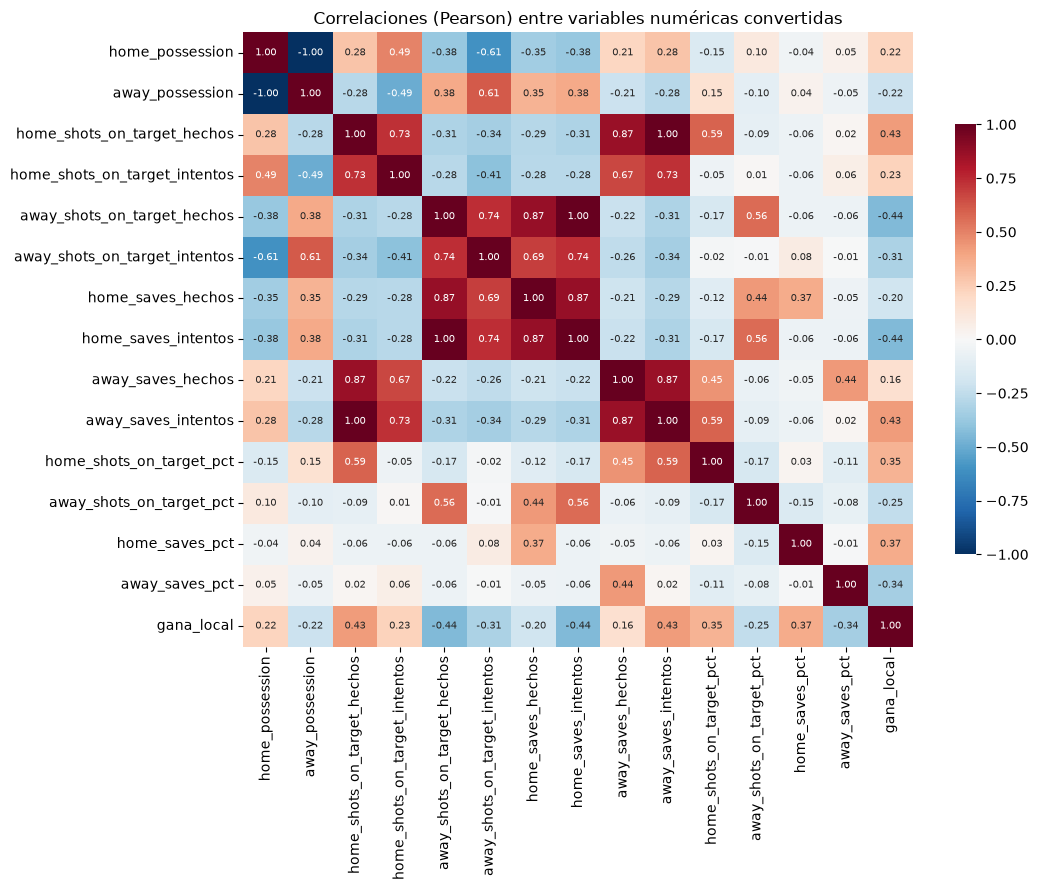

Correlación con gana_local (ordenada):
home_saves_intentos             -0.439
away_shots_on_target_hechos     -0.439
away_saves_pct                  -0.336
away_shots_on_target_intentos   -0.315
away_shots_on_target_pct        -0.246
away_possession                 -0.218
home_saves_hechos               -0.203
away_saves_hechos                0.161
home_possession                  0.219
home_shots_on_target_intentos    0.232
home_shots_on_target_pct         0.350
home_saves_pct                   0.370
home_shots_on_target_hechos      0.427
away_saves_intentos              0.427
Name: gana_local, dtype: float64


In [14]:
corr_df = num.copy()
corr_df["gana_local"] = (y == "Home Win").astype(int)
corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f",
            annot_kws={"size": 7}, ax=ax, cbar_kws={"shrink": 0.7})
ax.set_title("Correlaciones (Pearson) entre variables numéricas convertidas")
plt.tight_layout()
plt.show()

print("Correlación con gana_local (ordenada):")
print(corr["gana_local"].drop("gana_local").sort_values().round(3))

**Interpretación:** lo más correlacionado con que gane el local son los tiros a puerta
acertados del local (+0.427) y los del visitante (−0.439), seguidos del porcentaje de
atajadas del portero local (+0.370) y del porcentaje de tiros a puerta local (+0.350).
La posesión pesa mucho menos (+0.219): tener el balón no es lo mismo que ganar. Fíjate
también en los pares que salen con el mismo número (`away_shots_on_target_hechos` y
`home_saves_intentos`, ambos −0.439): son **la misma columna** con otro nombre, como
vimos en 7.2. Coincide con la Actividad 1 ("las variables que más pesaron fueron
los porcentajes de atajadas y de tiros a puerta"). Además `home_possession` y
`away_possession` tienen correlación ≈ −1 entre sí (suman 100): una es redundante.

## 9. Gráficos por clase
Boxplots: ¿cómo se distribuye cada variable según el resultado?

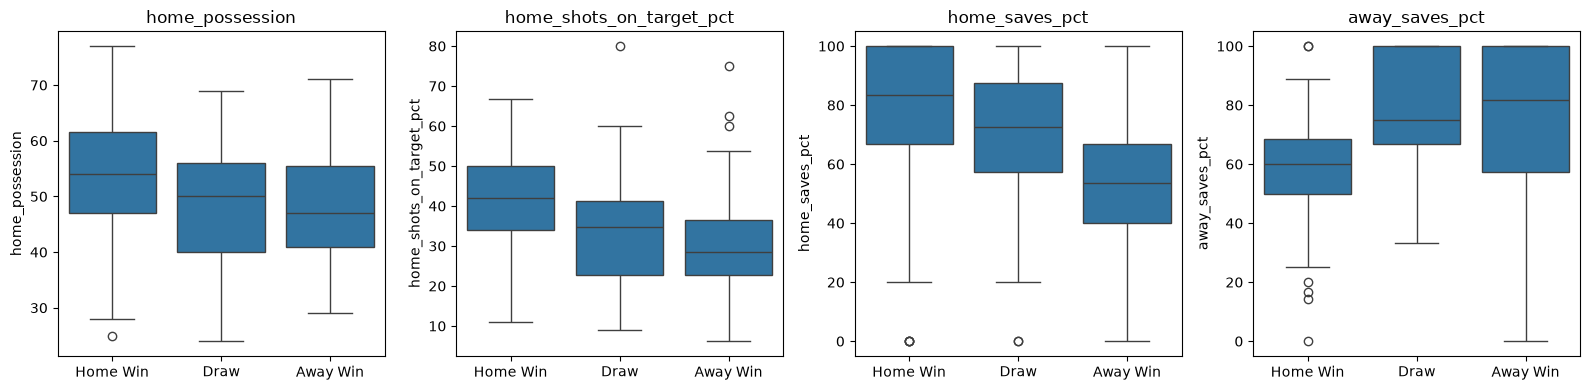

          home_possession  home_shots_on_target_pct  home_saves_pct  away_saves_pct
result                                                                             
Home Win             54.0                      42.1            83.3            60.0
Draw                 50.0                      34.8            72.5            75.0
Away Win             47.0                      28.6            53.6            81.6


In [15]:
graf = num[["home_possession", "home_shots_on_target_pct", "home_saves_pct", "away_saves_pct"]].copy()
graf["result"] = y
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
orden = ["Home Win", "Draw", "Away Win"]
for ax, col in zip(axes, graf.columns[:-1]):
    sns.boxplot(data=graf, x="result", y=col, order=orden, ax=ax)
    ax.set_title(col); ax.set_xlabel("")
plt.tight_layout()
plt.show()

print(graf.groupby("result")[graf.columns[:-1].tolist()].median().loc[orden].round(1))

**Interpretación:** la posesión separa poco las clases (mediana 54 % cuando gana el
local contra 47 % cuando gana la visita, con cajas muy traslapadas); el porcentaje de
atajadas separa mucho más: cuando gana el local su portero ataja una mediana de 83.3 % y
el visitante 60.0 %; cuando gana la visita es al revés (53.6 % contra 81.6 %). **Los empates quedan en medio y se
traslapan con las otras dos clases**: por eso todos los modelos del curso fallan más en
`Draw` (f1 de 0.286 en la Actividad 1 y 0.364 en la Actividad 3).

## 10. Variables categóricas: ¿cuánta información traen los equipos?

In [16]:
apariciones = pd.concat([df["home_team"], df["away_team"]]).value_counts()
print("Equipos distintos:", apariciones.size)
print("Partidos por equipo:", apariciones.describe()[["min", "mean", "max"]].round(1).to_dict())
print("Árbitros distintos:", df["referee"].nunique(), "| Estadios distintos:", df["venue"].nunique())

Equipos distintos: 36
Partidos por equipo: {'min': 8.0, 'mean': 8.0, 'max': 8.0}
Árbitros distintos: 42 | Estadios distintos: 38


**Interpretación:** 36 equipos y cada uno aparece en **8 partidos** (4 de local y 4 de
visita, el formato de liga de la Champions 2025/26). Un One-Hot de `home_team` y
`away_team` crea 72 columnas, cada una con apenas 4 "unos": casi ruido. Eso explica dos
cosas del curso: las **86 columnas** que salen del preprocesamiento (14 numéricas + 72 de
equipos) y que en la Actividad 3 `SelectKBest` con k=30 rindiera mejor que usar todas, y
que la importancia por permutación dejara a los equipos en casi cero. Árbitro y estadio
(42 y 38 valores para 144 filas) se descartan por la misma razón.

## Resumen

| Hallazgo del EDA | Evidencia (este notebook) | Decisión en el curso |
|---|---|---|
| 7 filas vacías cada 19 filas | separan 8 bloques de 18 partidos | `dropna(how="all")` → 144 partidos (Act. 1, Ej. 3) |
| Posesión como texto `'63%'` | 132 partidos suman 100, 12 suman 101 (redondeo) | transformador `PorcentajeATexto` |
| Tiros/atajadas como `'3 of 10'` | hechos/intentos reproduce el `*_pct` al 100 % | transformador `RatioATexto` (2 columnas por cada una) |
| 3 nulos en `home_saves_pct` | son `'0 of 0'` (división entre cero) | `SimpleImputer(strategy="median")` |
| Objetivo desbalanceado 71/48/25 | baseline 49.3 % | `stratify=y`, métrica `f1_macro`, `class_weight="balanced"` (Act. 3) |
| `score` y `winner` revelan el resultado | reconstruyen `result` al 100 %; árbol con diferencia de goles = 1.000 | se eliminan siempre (`LEAKAGE_COLUMNS`) |
| Tiros − atajadas ≈ goles | cruces al 100 %; la resta recupera el 84.7 % de los resultados | limitación documentada: el modelo explica, no predice antes del partido |
| 36 equipos, 8 partidos cada uno | One-Hot = 72 columnas casi vacías | `OneHotEncoder(handle_unknown="ignore")` + `SelectKBest` (Act. 3) |
| `date`, `venue`, `referee` | alta cardinalidad / no aportan | se descartan en el filtrado |

La lección MLOps: el EDA no es un trámite. Cada hallazgo se volvió **código versionado**
dentro del pipeline, de modo que la misma limpieza se aplica en entrenamiento, en
prueba y a cada dato nuevo que llega a la API.